## K-means Clustering

In this part we use the unlabelled rows of the train set to classify the label with K-means: we check whether the clusters of the rows follow the label, then we give each cluster the majority label of its labelled rows.

### Main observations

- **Rows:** The train set has 175 labelled rows and 321 unlabelled ones.
- **Number of clusters:** The inertia has no clear elbow, and the silhouette stays between 0.23 and 0.40. The rows do not form a clear number of clusters.
- **Cluster assumption:** It holds in part. The clusters are purer in label than clusters filled at random, 0.74 against 0.62 for k = 40, but far from pure. Many clusters hold no labelled row.
- **Cluster-then-label:** The unlabelled rows lower the F1 for almost every k, 0.60 against 0.69 for k = 40. With the labelled rows only, the F1 rises with k up to 0.81 for k = 130, the level of the k-NN classifier of `1D`, because each cluster then holds about one row.
- **Labelled and unlabelled rows:** A random forest tells them apart from their inputs with an AUC of 0.946. 220 of the 321 unlabelled rows were never tested for Charpy, and their inputs differ, P and voltage first. This most likely explains why the unlabelled rows make K-means worse.
- **Conclusion:** K-means does not help to classify the label with these inputs, and the unlabelled rows make it worse.

### Operations in order

1. Load the train set and build one row per `input_group`, labelled or not.
2. Fit K-means on all the rows for k from 2 to 130, and plot the inertia and the silhouette score to look for an elbow.
3. Fit K-means on all the rows and compare the label purity of the clusters with that of clusters filled at random.
4. Cross-validate cluster-then-label on the folds of `helpers/utils.py`, with and without the unlabelled rows.
5. Train a random forest to tell the labelled rows from the unlabelled ones, and list the targets measured on the unlabelled rows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, silhouette_score
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    SEED, N_FOLDS, TARGETS, INPUT_COLS, PWHT_COLS, DEPOSIT_COLS,
    load_train, load_results, true_criteria, deposit_labels, deposit_data,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

### One row per input_group

In [3]:
def one_row_per_group(df):
    """One row per input_group, labelled or not, built as in deposit_data. `true_nc` is NaN for an unlabelled row."""
    crit = true_criteria(df)
    labels = deposit_labels(df, crit, crit)
    groups = df.groupby("input_group")
    pwht = df.sort_values(PWHT_COLS).groupby("input_group")[PWHT_COLS]
    data = pd.concat([
        groups[[c for c in INPUT_COLS if c not in PWHT_COLS]].first(),
        pwht.first().add_suffix("_low"),
        pwht.last().add_suffix("_high"),
        groups[["fold", "family"]].first(),
    ], axis=1)
    data["true_nc"] = labels["true_nc"].reindex(data.index)
    return data


train = load_train()
table = one_row_per_group(train)

X = table[DEPOSIT_COLS].to_numpy()
y = table["true_nc"].to_numpy()
fold = table["fold"].to_numpy()
labelled = ~np.isnan(y)

print("Same inputs and labels as deposit_data:", table[labelled][DEPOSIT_COLS + ["true_nc"]].equals(deposit_data(train)[DEPOSIT_COLS + ["true_nc"]].astype({"true_nc": float})))
pd.crosstab(table["fold"], table["true_nc"].map({0: "good", 1: "bad"}).fillna("unlabelled"), margins=True)

Same inputs and labels as deposit_data: True


true_nc,bad,good,unlabelled,All
fold,,,,
0,17,18,64,99
1,17,15,67,99
2,17,20,62,99
3,15,21,64,100
4,17,18,64,99
All,83,92,321,496


- **Rows:** 496 rows, of which 175 are labelled: 83 bad and 92 good. The other 321 have no label. Each fold holds 99 or 100 rows, of which 62 to 67 are unlabelled.
- **Check:** The labelled rows have the same inputs and labels as `deposit_data`, so the results compare with those of the `1D` notebooks.

### Number of clusters

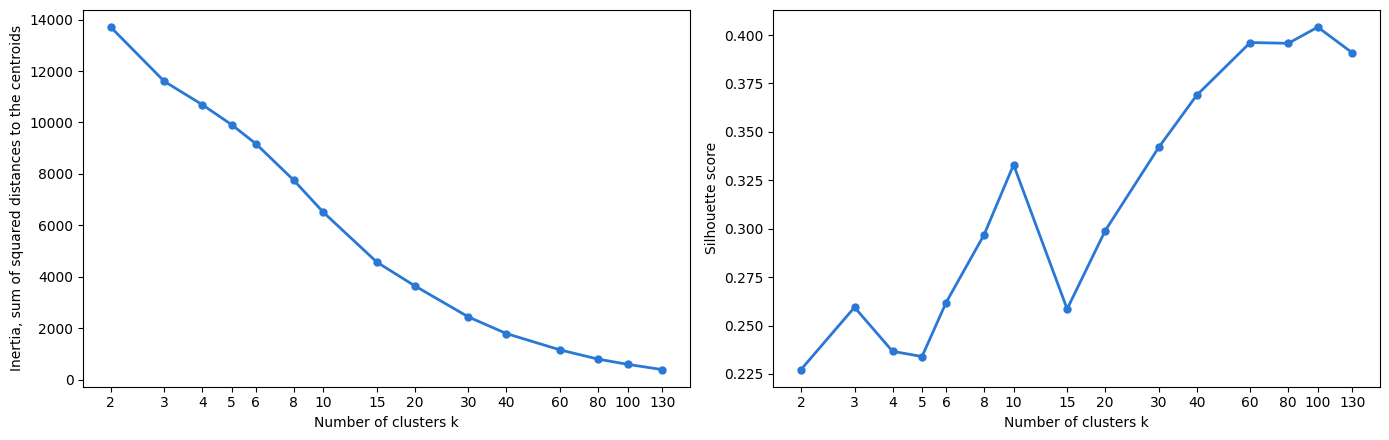

,inertia,silhouette
k,,
2,13708.339,0.227
3,11598.319,0.259
4,10692.162,0.237
5,9909.004,0.234
6,9173.955,0.262
8,7749.304,0.297
10,6506.998,0.333
15,4566.478,0.259
20,3642.640,0.299


In [4]:
scaled = StandardScaler().fit_transform(X)

k_values = [2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 40, 60, 80, 100, 130]
elbow = pd.DataFrame(index=pd.Index(k_values, name="k"), columns=["inertia", "silhouette"], dtype=float)
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(scaled)
    elbow.loc[k] = [kmeans.inertia_, silhouette_score(scaled, kmeans.labels_)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, column, name in zip(axes, ["inertia", "silhouette"], ["Inertia, sum of squared distances to the centroids", "Silhouette score"]):
    ax.plot(elbow.index, elbow[column], color="#2a78d6", linewidth=2, marker="o", markersize=5)
    ax.set_xscale("log")
    ax.set_xticks(k_values, k_values)
    ax.minorticks_off()
    ax.set_xlabel("Number of clusters k")
    ax.set_ylabel(name)
plt.tight_layout()
plt.show()

elbow.round(3)

- **Inertia:** It falls smoothly from 13,708 for k = 2 to 388 for k = 130. There is no clear elbow.
- **Silhouette:** Between 0.23 and 0.40 for every k, so the clusters overlap. It has a small peak at k = 10, 0.33, then rises again up to 0.40 for k = 60 to 130.
- **Verdict:** The rows do not form a clear number of clusters.

### Cluster assumption

In [5]:
def purity(clusters, labels):
    """Share of the labelled rows that have the majority label of their cluster."""
    counts = pd.crosstab(clusters, labels)
    return counts.max(axis=1).sum() / counts.to_numpy().sum()


rng = np.random.default_rng(SEED)

rows = []
for k in [2, 5, 10, 20, 40, 80, 130]:
    clusters = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(scaled)
    shuffled = [purity(clusters[labelled], rng.permutation(y[labelled])) for _ in range(200)]
    rows.append({
        "k": k,
        "purity": purity(clusters[labelled], y[labelled]),
        "purity_random_labels": np.mean(shuffled),
        "random_labels_95th_percentile": np.percentile(shuffled, 95),
        "clusters_without_labelled_row": k - len(np.unique(clusters[labelled])),
    })

pd.DataFrame(rows).set_index("k").round(3)

,purity,purity_random_labels,random_labels_95th_percentile,clusters_without_labelled_row
k,,,,
2,0.634,0.533,0.555,0
5,0.634,0.551,0.589,1
10,0.657,0.565,0.600,2
20,0.691,0.587,0.623,8
40,0.737,0.616,0.657,22
80,0.760,0.655,0.697,48
130,0.834,0.694,0.726,84


The purity is the share of the labelled rows that have the majority label of their cluster. Small clusters are pure by chance, so the same clusters with randomly shuffled labels give the purity to beat.

- **Purity:** Above the random labels for every k, and above their 95th percentile: 0.63 against 0.53 for k = 2, 0.74 against 0.62 for k = 40, 0.83 against 0.69 for k = 130. The clusters carry some information on the label, so the cluster assumption holds in part.
- **Gap:** The clusters are far from pure. For k = 40, 26% of the labelled rows do not have the majority label of their cluster.
- **Clusters without label:** 22 of the 40 clusters hold no labelled row, 48 of the 80 and 84 of the 130. Many unlabelled rows are in regions with no labelled row.

### Cluster-then-label

In [6]:
def cluster_then_label(k, use_unlabelled):
    """Out-of-fold label of each labelled row.

    For each fold, K-means is fitted on the rows of the 4 other folds, with or without the
    unlabelled ones. Each cluster takes the majority label of its labelled rows, bad on a tie,
    and the majority label of the 4 folds when it holds no labelled row. A row of the fold
    takes the label of its nearest cluster.
    """
    pred = np.full(len(y), np.nan)
    for f in range(N_FOLDS):
        fit = (fold != f) & (labelled | use_unlabelled)
        known = (fold != f) & labelled
        val = (fold == f) & labelled
        scaler = StandardScaler().fit(X[fit])
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(scaler.transform(X[fit]))
        clusters = kmeans.predict(scaler.transform(X[known]))
        default = int(y[known].mean() >= 0.5)
        vote = pd.Series(y[known]).groupby(clusters).mean().ge(0.5).astype(int).reindex(range(k), fill_value=default)
        pred[val] = vote.to_numpy()[kmeans.predict(scaler.transform(X[val]))]
    return pred[labelled].astype(int)


true_nc = y[labelled].astype(int)
rows = []
for k in [2, 5, 10, 20, 40, 80, 130]:
    for use_unlabelled in [False, True]:
        pred = cluster_then_label(k, use_unlabelled)
        rows.append({
            "k": k,
            "rows": "labelled + unlabelled" if use_unlabelled else "labelled only",
            "F1": f1_score(true_nc, pred),
            "recall": recall_score(true_nc, pred),
            "precision_good": precision_score(true_nc == 0, pred == 0, zero_division=0),
        })

kmeans_results = pd.DataFrame(rows).pivot(index="k", columns="rows").reindex(columns=["labelled only", "labelled + unlabelled"], level="rows")
kmeans_results.round(2)

F1                              recall                        \
rows labelled only labelled + unlabelled labelled only labelled + unlabelled   
k                                                                              
2             0.43                  0.28          0.28                  0.17   
5             0.41                  0.41          0.27                  0.28   
10            0.63                  0.48          0.66                  0.35   
20            0.66                  0.55          0.70                  0.53   
40            0.69                  0.60          0.70                  0.59   
80            0.70                  0.65          0.75                  0.73   
130           0.81                  0.69          0.83                  0.73   

     precision_good                        
rows  labelled only labelled + unlabelled  
k                                          
2              0.61                  0.56  
5              0.59                  0.59  
10             0.67                  0.60  
20             0.70                  0.61  
40             0.72                  0.64  
80             0.74                  0.69  
130            0.84                  0.73

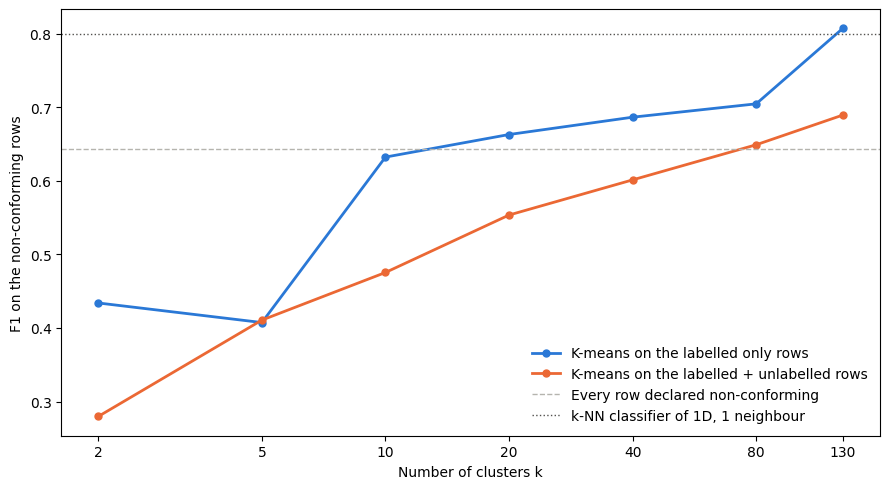

In [7]:
reference = 2 * true_nc.mean() / (1 + true_nc.mean())
knn_f1 = load_results().query("model == 'k-NN classifier' and target == 'label' and family == 'all'")["F1_nc"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))
for rows_used, color in [("labelled only", "#2a78d6"), ("labelled + unlabelled", "#eb6834")]:
    ax.plot(kmeans_results.index, kmeans_results[("F1", rows_used)], color=color, linewidth=2, marker="o", markersize=5, label=f"K-means on the {rows_used} rows")
ax.axhline(reference, color="#b5b4ae", linewidth=1, linestyle="--", label="Every row declared non-conforming")
ax.axhline(knn_f1, color="#52514e", linewidth=1, linestyle=":", label="k-NN classifier of 1D, 1 neighbour")
ax.set_xscale("log")
ax.set_xticks(kmeans_results.index, kmeans_results.index)
ax.minorticks_off()
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("F1 on the non-conforming rows")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Cluster-then-label: for each fold, K-means is fitted on the 4 other folds. Each cluster predicts the mean label of its labelled rows, so a cluster is bad when half or more of its labelled rows are bad. Each row of the fold takes the label of its nearest cluster. The dashed line is the rule that declares every row non-conforming, the dotted line the k-NN classifier of `1D`.

- **Unlabelled rows:** They lower the F1 for every k except k = 5, where both give 0.41: 0.60 against 0.69 for k = 40, 0.69 against 0.81 for k = 130. Most likely, the clusters go to the regions without labelled rows of the previous table, so fewer clusters are left for the labelled ones.
- **More clusters:** With the labelled rows only, the F1 rises with k up to 0.81 for k = 130, the level of the k-NN classifier, 0.80. The 4 training folds hold 138 to 143 labelled rows, so with 130 clusters almost every cluster holds a single row, and the method becomes a nearest neighbour classifier. The F1 rises because the clusters get smaller, not because they follow the label.
- **No elbow:** The F1 keeps rising until the method is a nearest neighbour classifier.
- **Small k:** For k = 2 and 5, the F1 is below the dashed line. The recall falls to 0.17 to 0.28: most bad rows are declared good.
- **Choice of k:** k is not tuned. The peak of the silhouette, k = 10, gives an F1 of 0.63 with the labelled rows only and 0.48 with the unlabelled ones.

### Labelled and unlabelled rows

A random forest learns to tell a labelled row from an unlabelled one, from the inputs only, on the same folds. An AUC of 0.5 means that the two groups look the same, an AUC of 1 that they are fully separated.

In [8]:
unlabelled = (~labelled).astype(int)
score = np.zeros(len(y))
for f in range(N_FOLDS):
    forest = RandomForestClassifier(n_estimators=300, random_state=SEED).fit(X[fold != f], unlabelled[fold != f])
    score[fold == f] = forest.predict_proba(X[fold == f])[:, 1]
print("AUC, labelled against unlabelled rows:", round(roc_auc_score(unlabelled, score), 3))

forest = RandomForestClassifier(n_estimators=300, random_state=SEED).fit(X, unlabelled)
importance = pd.Series(forest.feature_importances_, index=DEPOSIT_COLS).sort_values(ascending=False).head(6)
pd.DataFrame({
    "importance": importance,
    "median_labelled": table.loc[labelled, importance.index].median(),
    "median_unlabelled": table.loc[~labelled, importance.index].median(),
}).round(3)

AUC, labelled against unlabelled rows: 0.946


,importance,median_labelled,median_unlabelled
P,0.088,0.008,0.013
Mn,0.067,1.350,1.180
voltage_V,0.062,21.000,30.000
Cr,0.062,0.000,0.049
C,0.058,0.074,0.074
O_ppm,0.055,423.000,423.000


- **AUC:** 0.946. The forest tells a labelled row from an unlabelled one in most cases, so the two groups are not a random split of the same rows.
- **Inputs that differ most:** P, with a median of 0.013 for the unlabelled rows against 0.008 for the labelled ones, and the voltage, 30 V against 21 V. Mn and Cr also differ. C and O_ppm have the same median in both groups.

In [9]:
measured = train[TARGETS].notna().groupby(train["input_group"]).any()
measured.loc[table.index[~labelled]].value_counts().rename("unlabelled_rows").to_frame()

unlabelled_rows
yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J                 
True               True    True           False                           144
                                          True                             73
                           False          False                            20
                   False   False          False                            19
                                          True                             14
False              True    False          False                            12
                   False   False          False                            12
                                          True                              9
True               False   True           False                             8
False              False   True           False                             5
True               True    False          True                              3
False              True    False          True                              2

The targets measured on each of the 321 unlabelled rows.

- **No Charpy:** 220 of the 321 rows have no Charpy value, of which 144 have the three other targets. These rows have no label because they were never tested for Charpy.
- **All four measured:** 73 rows have the four targets but still no label, because one criterion is not decided, for example a Charpy test on the wrong side of the reference temperature.
- **Nothing measured:** 12 rows have no target at all.